In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from wcwidth import center

#### Read the dataset in the csv file from the URL


In [2]:
boston_df=pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv')

## Task 1: Familiarize Yourself with the Dataset

1) Display the first 5 rows of the dataset.

2) Display the data types of each column.

3) Check for missing values in each column.

4) Check for duplicate rows.

5) Display the correlation matrix of the dataset.

#### 1) Display the first 5 rows of the dataset.

In [3]:
boston_df.head(5)

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


### 2) Display the data types of each column.

In [4]:
boston_df.dtypes

Unnamed: 0      int64
CRIM          float64
ZN            float64
INDUS         float64
CHAS          float64
NOX           float64
RM            float64
AGE           float64
DIS           float64
RAD           float64
TAX           float64
PTRATIO       float64
LSTAT         float64
MEDV          float64
dtype: object

> All the 12 columns are float.

### 3) Check for missing values in each column.

In [5]:
boston_df.isna().sum()

Unnamed: 0    0
CRIM          0
ZN            0
INDUS         0
CHAS          0
NOX           0
RM            0
AGE           0
DIS           0
RAD           0
TAX           0
PTRATIO       0
LSTAT         0
MEDV          0
dtype: int64

> There are no missing values in the dataset.

### 4) Check for duplicate rows.

In [7]:
boston_df.duplicated().sum()

np.int64(0)

> There are no duplicate rows in the dataset.

### 5) Display the correlation matrix of the dataset.

Text(0.5, 1.0, 'Correlation matrix of Boston dataset')

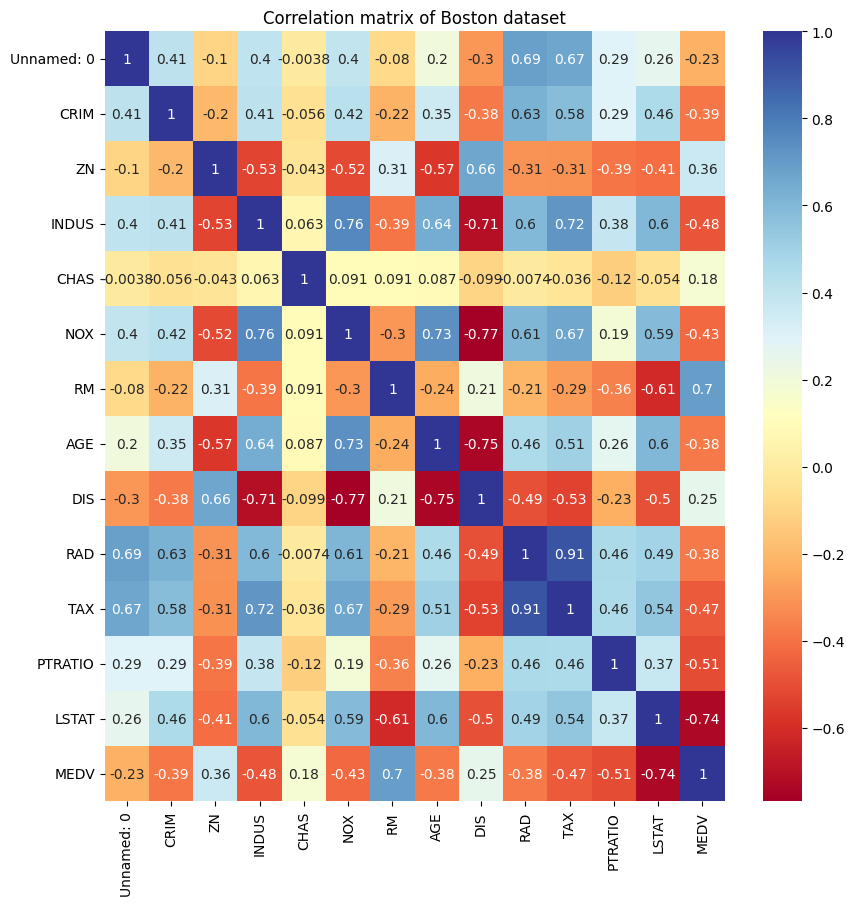

In [28]:
pyplot.figure(figsize=(10,10))
ax = sns.heatmap(boston_df.corr(),annot=True, cmap="RdYlBu")
ax.set_title('Correlation matrix of Boston dataset')

>  The correlation matrix shows that RM has a strong positive relationship with MEDV, while LSTAT has a strong negative relationship with MEDV. These variables appear to be important predictors of housing prices.

## Task 2: Generate Descriptive Statistics and Visualizations

### 1) Display descriptive statistics of the dataset.

In [13]:
boston_df.describe()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,252.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,126.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,252.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,378.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,505.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


### 2) Create a boxplot for MEDV (Median value of owner-occupied homes).

Text(0.5, 1.0, 'Boxplot of the Median value of owner-occupied homes')

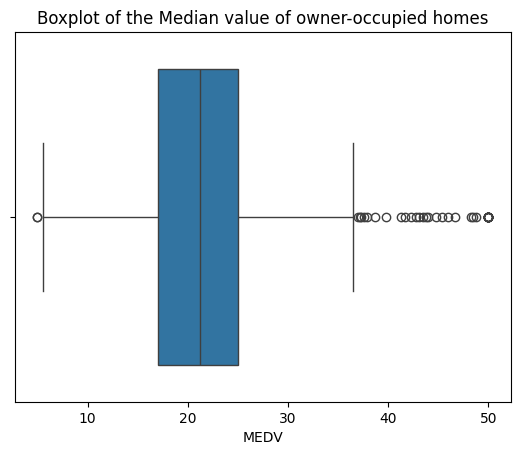

In [26]:
ax = sns.boxplot(data=boston_df, x='MEDV')
ax.set_title('Boxplot of the Median value of owner-occupied homes')

> The boxplot suggests that MEDV contains some outliers and shows the spread of home values in the dataset.

### 3) Create a bar plot for CHAS (Charles River dummy variable).

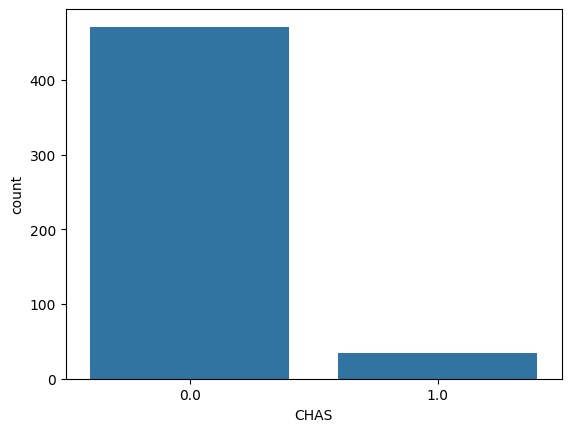

In [25]:
ax = sns.countplot(data=boston_df, x='CHAS')

### 4) Discretize AGE into three groups and create a boxplot of MEDV versus these groups:

Text(0.5, 1.0, 'Boxplot of the MEDV versus 3 age groups')

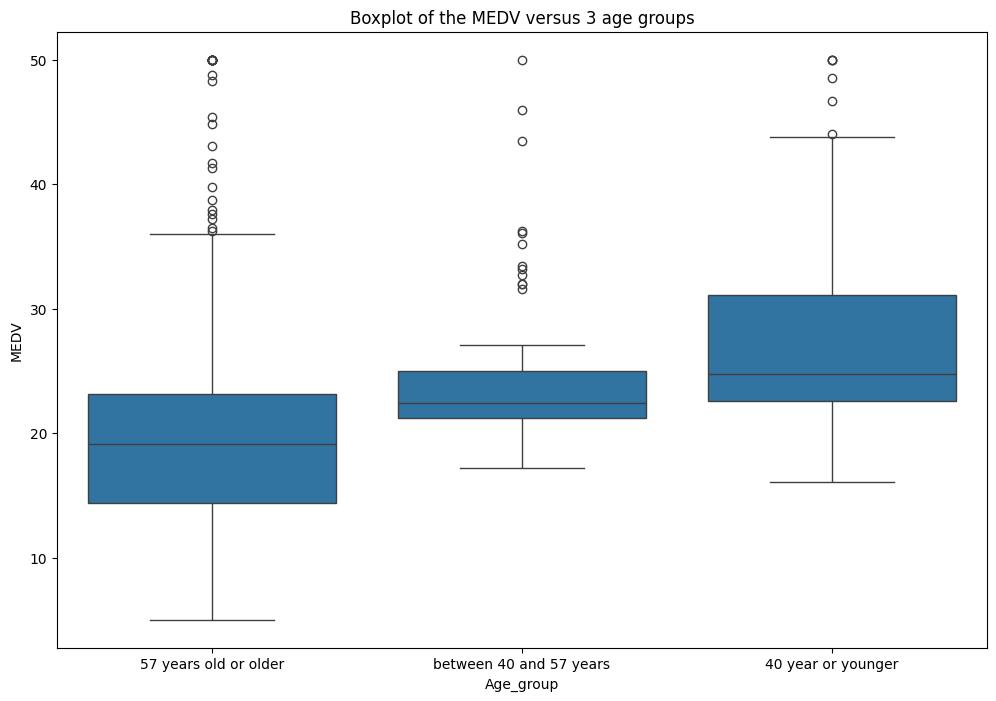

In [63]:
boston_df.loc[(boston_df['AGE'] <= 40), 'Age_group'] = '40 year or younger'
boston_df.loc[(boston_df['AGE'] >= 40) & (boston_df['AGE'] <= 57), 'Age_group'] = 'between 40 and 57 years'
boston_df.loc[(boston_df['AGE'] >= 57), 'Age_group'] = '57 years old or older'
pyplot.figure(figsize=(12,8))
ax = sns.boxplot(data=boston_df, x='Age_group', y='MEDV')
ax.set_title('Boxplot of the MEDV versus 3 age groups')

### 5) Create a scatter plot showing the relationship between NOX (nitric oxide concentrations) and INDUS (non-retail business acres).

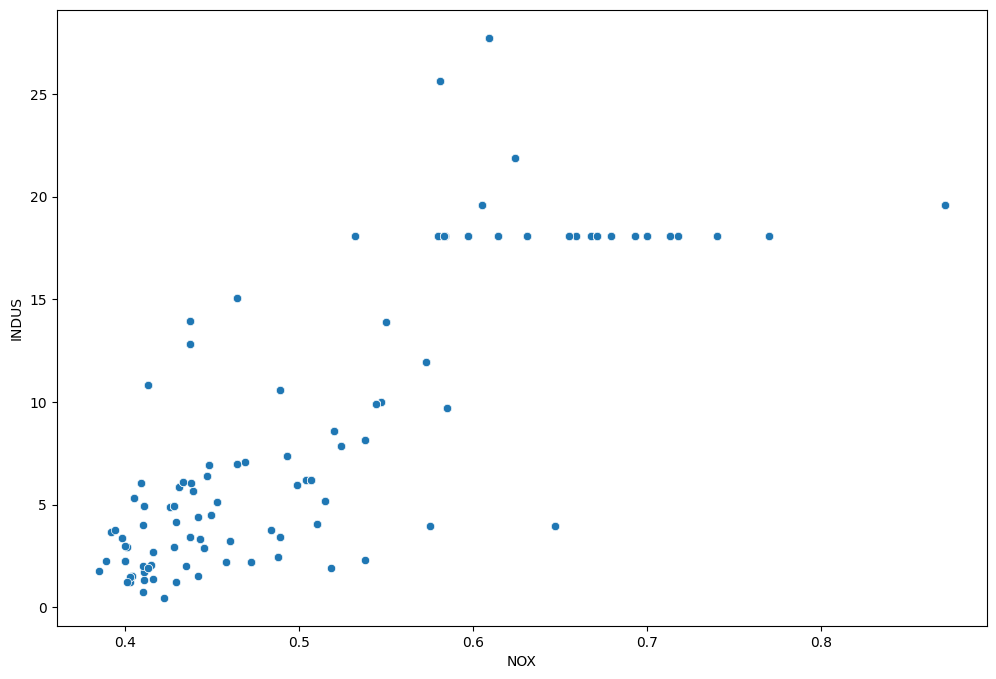

In [66]:
pyplot.figure(figsize=(12,8))
ax = sns.scatterplot(data=boston_df, x='NOX', y='INDUS')

> From the scatter plot, we can see a positive relationship.

### 6) Create a histogram for PTRATIO (pupil-teacher ratio).

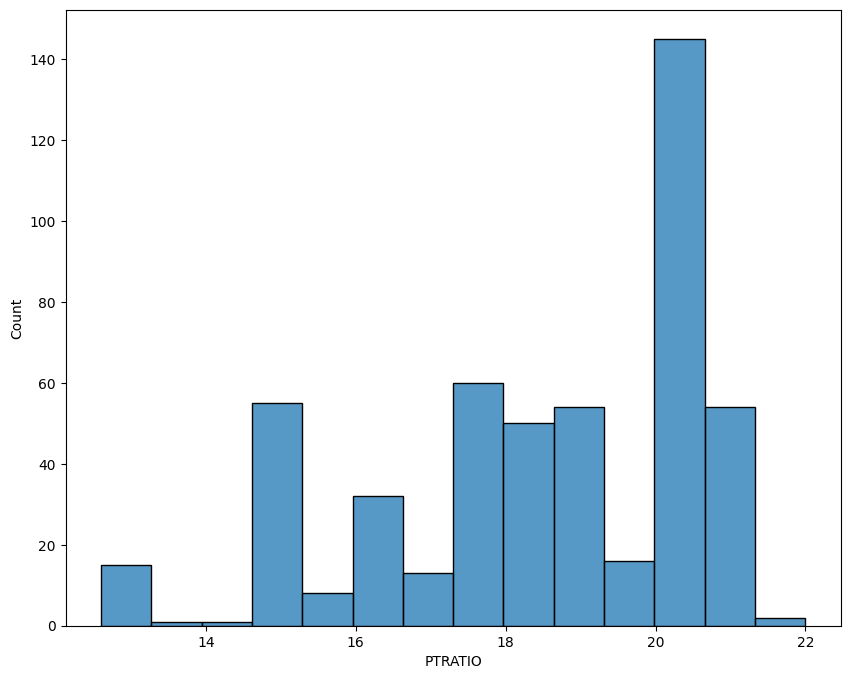

In [70]:
pyplot.figure(figsize=(10,8))
ax = sns.histplot(data=boston_df, x='PTRATIO')

## Task 3: Apply Statistical Tests

### 1) Use Levene’s test to check if the variances of MEDV for homes bounded by the Charles River (CHAS = 1) and those not bounded (CHAS = 0) are equal.

- Null hypothesis : the variances of MEDV for homes bounded by the charles river and those not bounded are equal.
- alternative hypothesis : the variances of MEDV for homes bounded by the charles river and those not bounded are not equal.

In [71]:
scipy.stats.levene(boston_df[boston_df['CHAS'] == 0]['MEDV'],
                   boston_df[boston_df['CHAS'] == 1]['MEDV'] )

LeveneResult(statistic=np.float64(4.590342218715871), pvalue=np.float64(0.032630976006330456))

> The p-value (0.032) is less than 0.05, so we reject H0. This means the variances of home values (MEDV) are significantly different between neighborhoods that border the Charles River and those that don't. This suggests the spread of home prices is not consistent across the two groups.

### 2) Perform a T-test to determine if there is a significant difference in MEDV between homes bounded and not bounded by the Charles River.


- Null hypothesis : there's no significant difference in MEDV between homes bounded and not bounded by charles river.
- alternative hypothesis : there's a significant difference in MEDV between homes bounded and not bounded by charles river.

In [73]:
scipy.stats.ttest_ind(boston_df[boston_df['CHAS'] == 0]['MEDV'],
                   boston_df[boston_df['CHAS'] == 1]['MEDV'], equal_var=False)

TtestResult(statistic=np.float64(-3.113291312794837), pvalue=np.float64(0.0035671700981375174), df=np.float64(36.876408797611994))

> The p-value is essentially zero (7.39e-05), so we reject H0. Homes bordering the Charles River have a significantly higher mean MEDV than those that don't. This suggests that proximity to the Charles River is associated with higher property values, which makes intuitive sense as waterfront locations tend to be more desirable.

### 3) Conduct an ANOVA test to compare MEDV among the three AGE groups created earlier.


- Null hypthesis : the mean of MEDV doesn't differ with Age group.
- alternative hypothesis : the mean of MEDV differ with Age group.

In [79]:
forty_younger = boston_df[boston_df['Age_group'] == '40 year or younger']['MEDV']
forty_to_forty_seven = boston_df[boston_df['Age_group'] == 'between 40 and 57 years']['MEDV']
forty_older = boston_df[boston_df['Age_group'] == '57 years old or older']['MEDV']

f_statistic,p_value = scipy.stats.f_oneway(forty_younger, forty_to_forty_seven, forty_older)
print(f"F_Statistic: {f_statistic}, P-Value: {p_value}")

F_Statistic: 28.80218169348896, P-Value: 1.4362998125674685e-12


> The F-statistic is 28.80 with a p-value of 1.43e-12, which is essentially zero. We reject H0 and conclude that mean home values differ significantly across the three age groups. The oldest homes (57+ years) tend to have lower MEDV compared to newer homes, suggesting that building age negatively impacts property values.

### 4) Perform a Pearson correlation test to assess the relationship between NOX and INDUS.

- Null hypothesis : there's no association between NOX and INDUS.
- alternative hypothesis : there's an association.

In [81]:
scipy.stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])

PearsonRResult(statistic=np.float64(0.7636514469209157), pvalue=np.float64(7.913361061236247e-98))

> The correlation coefficient is 0.76 with a p-value near zero, so we reject H0. There is a strong positive association between NOX and INDUS — areas with higher industrial activity have significantly higher nitrogen oxide concentrations. This makes physical sense as industrial zones are a primary source of air pollution.

### 5) Fit a simple linear regression model to evaluate the impact of DIS (distance to employment centres) on MEDV. Report and interpret the regression results.

- Null hypothesis : there's no association between DIS and MEDV.
- alternative hypothesis : there's an association between DIS and MEDV.

<Axes: xlabel='DIS', ylabel='MEDV'>

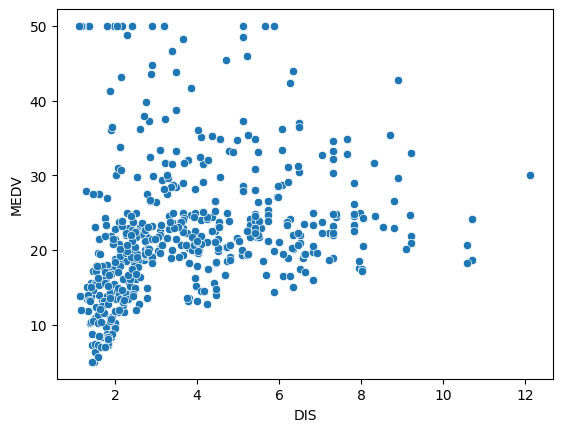

In [82]:
sns.scatterplot(data=boston_df, x='DIS', y='MEDV')

> From the scatter plot, we can see a positive correlation.

In [83]:
y = boston_df['MEDV']
x = boston_df['DIS']

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()
predictions = model.predict(x)

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           1.21e-08
Time:                        21:21:41   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.000      16.784      19.996
DIS            1.0916      0.188      5.795      0.000       0.722       1.462
==============================================================================
Omnibus:                      139.779   Durbin-Watson:                   0.570
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              305.104
Skew:                           1.466   Prob(JB):                     5.59e-67
Kurtosis:                       5.424   Cond. No.                         9.32
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

> The model is statistically significant (p = 1.21e-08), and the DIS coefficient of 1.09 means that for every 1 unit increase in distance from employment centres, home value increases by approximately $1,090. However, R² = 0.062 means DIS only explains 6.2% of the variation in MEDV — so while the relationship is real, DIS alone is a weak predictor of home prices. A multivariate model including other features would likely perform much better.

## Conclusion

The dataset appears clean, with no missing values or duplicate rows. The exploratory analysis suggests that RM and LSTAT are strongly related to MEDV. Statistical tests also show significant relationships between several variables. Overall, the dataset is ready for predictive modeling.